In [1]:
from estimator import *
from estimator.lwe_guess import mitm

from sage.plot.graphics import Graphics
from sage.plot.plot import list_plot

def is_key_list(keys):
    return isinstance(keys, (list, tuple))

def entropy_rate(Dist, n, w):
    """
    Return entropy density H(D_n) / n in bits per coordinate.
    """

    if Dist == ND.CenteredBinomial:
        # You use Dist(2), so eta = 2.
        eta = 2

        # CBD_eta has probabilities:
        # P[X = j - eta] = binomial(2*eta, j) / 2^(2*eta)
        H = 0
        for j in range(2 * eta + 1):
            p = binomial(2 * eta, j) / RealField(100)(2)**(2 * eta)
            H -= p * log(p, 2)

        return H

    elif Dist == ND.SparseBinary:
        # exactly h ones
        h = int(n * w)

        # total entropy = log_2 binomial(n, h)
        return log(binomial(n, h), 2) / n

    elif Dist == ND.SparseTernary:
        # your convention: h positives and h negatives
        h = int(n * w / 2)

        # choose h positions for +1, then h positions for -1
        # total support size = binomial(n, h) * binomial(n - h, h)
        return (
            log(binomial(n, h), 2)
            + log(binomial(n - h, h), 2)
        ) / n

    else:
        raise ValueError(f"Unknown distribution: {Dist}")

def extract_series(stats, Dist, keys):
    """
    If keys is a string:
        return [(n, value), ...]

    If keys is a list/tuple of strings:
        return {key: [(n, value), ...], ...}
    """
    if is_key_list(keys):
        return {
            key: extract_series(stats, Dist, key)
            for key in keys
        }

    key = keys
    return [
        (n, stats[Dist][n][key])
        for n in sorted(stats[Dist].keys())
        if key in stats[Dist][n]
    ]


def log2_safe(x):
    if x <= 0:
        return None
    return log(x, 2)


def extract_series_log2(stats, Dist, keys):
    """
    If keys is a string:
        return [(n, log_2(value)), ...]

    If keys is a list/tuple of strings:
        return {key: [(n, log_2(value)), ...], ...}
    """
    if is_key_list(keys):
        return {
            key: extract_series_log2(stats, Dist, key)
            for key in keys
        }

    key = keys
    pts = []

    for n in sorted(stats[Dist].keys()):
        if key not in stats[Dist][n]:
            continue

        y = log2_safe(stats[Dist][n][key])
        if y is not None:
            pts.append((n, y))

    return pts


from sage.plot.graphics import Graphics
from sage.plot.plot import list_plot

def plot_series_for_distribution(stats, Dist, keys, title_prefix="", log2_y=False, marker="o"):
    G = Graphics()

    colors = ["red", "blue", "green", "orange", "purple", "black"]

    if log2_y:
        data = extract_series_log2(stats, Dist, keys)
        ylabel = "log_2(value)"
    else:
        data = extract_series(stats, Dist, keys)
        ylabel = "value"

    if isinstance(data, dict):
        for i, key in enumerate(keys):
            pts = data[key]
            label = f"log_2({key})" if log2_y else str(key)

            G += list_plot(
                pts,
                plotjoined=True,
                marker=marker,
                color=colors[i % len(colors)],
                legend_label=label,
            )
    else:
        label = f"log_2({keys})" if log2_y else str(keys)

        G += list_plot(
            data,
            plotjoined=True,
            marker=marker,
            legend_label=label,
        )

    G.axes_labels(["n", ylabel])
    G.legend(True)
    G.set_legend_options(loc="best")
    G.show(title=f"{title_prefix}{Dist}")

    return G

In [2]:
from estimator import *
from estimator.lwe_guess import guess_composition

from estimator.simulator import GSA, CN11
red_shape_model=CN11

distrib = [
    ND.SparseTernary,
    # ND.SparseBinary,
    # ND.CenteredBinomial,
]

q = 3329
dims = list(range(512, 1281, 128))
w = 0.33
ncpus = 8

stats_nomitm = {d: {} for d in distrib}
stats_mitm = {d: {} for d in distrib}

def make_noise(Dist, n, w):
    if Dist == ND.CenteredBinomial:
        return Dist(w)

    elif Dist == ND.SparseBinary:
        h = int(n * w)
        return Dist(h, n=n)

    elif Dist == ND.SparseTernary:
        h = int(n * w / 2)
        return Dist(h, n=n)

    else:
        raise ValueError(f"Unknown distribution: {Dist}")


def run_one_experiment(Dist, n, q, w):
    m = n
    d = n+m
    # print(f" - - - n={n}, D={Dist}")

    noise = make_noise(Dist, n, w)
    params = LWE.Parameters(n=n, m=m, q=q, Xs=noise, Xe=noise)

    # print(f"n={n}, D={Dist}: primal_hybrid, mitm=False, babai=False")

    """
    sigm = noise.stddev
    loggap = n * log( q, d ) - log( sigm, d )
    Bfrak = 1 / ( 1+2*loggap ) + 40/(d)  #beta = Bfrak*d and we want beta>=40 for more precise estimations
    HD = entropy_rate(Dist, n, w) #HD is the entropy of Dist, n, w
    Kfrak = Bfrak**2/(Bfrak + HD/0.058)
    
    zeta = round(Kfrak * d) + ceil( 0.667*ln(d-100)**1.5 )  # ceil(0.86*ln(n-100)**2-2)
    print(f"zeta: {zeta}")
    
    print( Dist, loggap.n(), Bfrak.n())
    tmp0 = LWE.primal_hybrid(params, mitm=False, babai=False, zeta=zeta) #[SAC:AlbCurWun19] 2019/1122
    """
    try:
        tmp0 = LWE.primal_meet(params, succ_prob=0.5, babai_dim=None) 
    except Exception as e:
        print(f"FAILED tmp0: n={n}, D={Dist}, error={repr(e)}")
        tmp1 = None
    
    try:
        tmp1 = LWE.primal_meet(params, succ_prob=0.5, babai_dim=45) 
    except Exception as e:
        print(f"FAILED tmp1: n={n}, D={Dist}, error={repr(e)}")
        tmp1 = None

    return Dist, n, tmp0, tmp1
    
# - - -

tasks = [
    (ND.SparseTernary, n, q, w)
    for n in dims ]

@parallel(ncpus=ncpus)
def run_one_experiment_parallel(Dist, n, q, w):
    return run_one_experiment(Dist, n, q, w)

stats_nomitm = {d: {} for d in distrib}
stats_mitm = {d: {} for d in distrib}

for inp, result in run_one_experiment_parallel(tasks):
    Dist, n, tmp0, tmp1 = result

    stats_nomitm[Dist][n] = tmp0
    stats_mitm[Dist][n] = tmp1

stats_nomitm_whole = {d: {} for d in distrib}
stats_mitm_whole = {d: {} for d in distrib}
failures = []

done = 0
total = len(tasks)
for inp, result in run_one_experiment_parallel(tasks):
    Dist, n, tmp0, tmp1 = result

    if tmp0 is not None:
        stats_nomitm_whole[Dist][n] = tmp0
    else:
        failures.append((Dist, n, "nomitm"))

    if tmp1 is not None:
        stats_mitm_whole[Dist][n] = tmp1
    else:
        failures.append((Dist, n, "mitm"))

    print(f"Collected n={n}, D={Dist}: tmp0={tmp0 is not None}, tmp1={tmp1 is not None}")
    done += 1
    print(f"Done {done}/{total}: n={n}, D={Dist}")


Collected n=512, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 1/7: n=512, D=<class 'estimator.nd.SparseTernary'>
Collected n=640, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 2/7: n=640, D=<class 'estimator.nd.SparseTernary'>
Collected n=768, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 3/7: n=768, D=<class 'estimator.nd.SparseTernary'>
Collected n=896, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 4/7: n=896, D=<class 'estimator.nd.SparseTernary'>
Collected n=1024, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 5/7: n=1024, D=<class 'estimator.nd.SparseTernary'>
Collected n=1152, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 6/7: n=1152, D=<class 'estimator.nd.SparseTernary'>
Collected n=1280, D=<class 'estimator.nd.SparseTernary'>: tmp0=True, tmp1=True
Done 7/7: n=1280, D=<class 'estimator.nd.SparseTernary'>


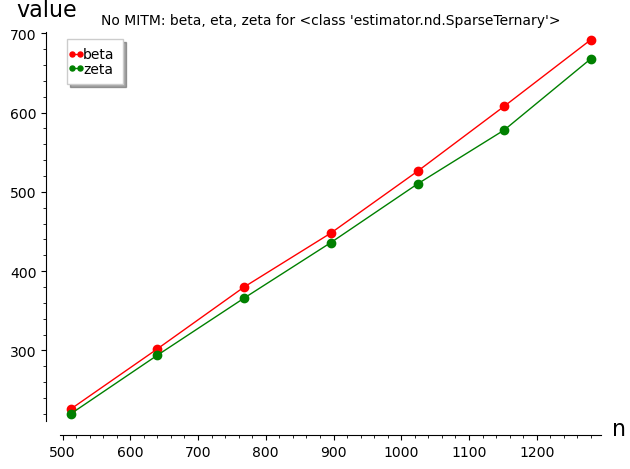

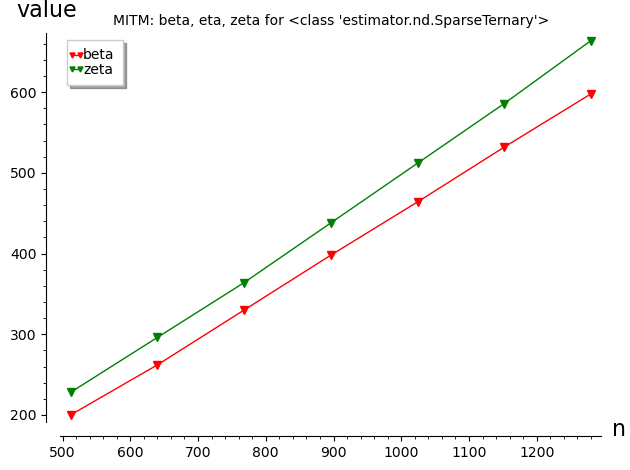

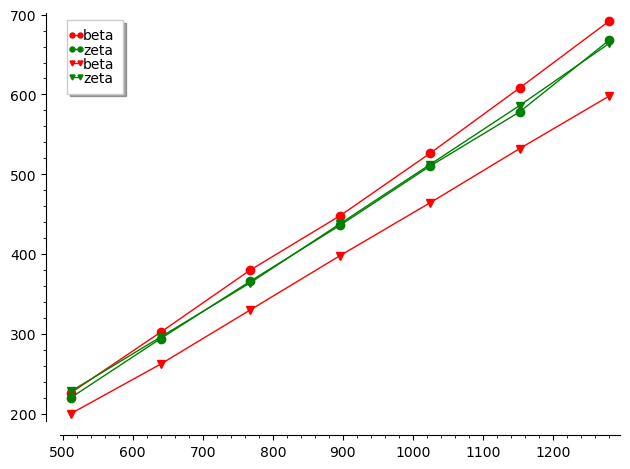

In [9]:
for Dist in distrib:
    Gbez0 = plot_series_for_distribution(
        stats_nomitm_whole, Dist, ["beta", "eta", "zeta"], 
        log2_y=False, title_prefix="No MITM: beta, eta, zeta for ")
    Gbez1 = plot_series_for_distribution(
        stats_mitm_whole, Dist, ["beta", "eta", "zeta"], 
        log2_y=False, title_prefix="MITM: beta, eta, zeta for ",
        marker="v")
    
(Gbez0+Gbez1).show()

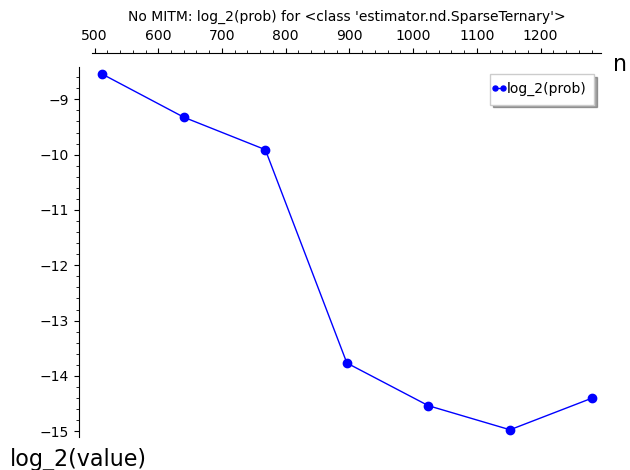

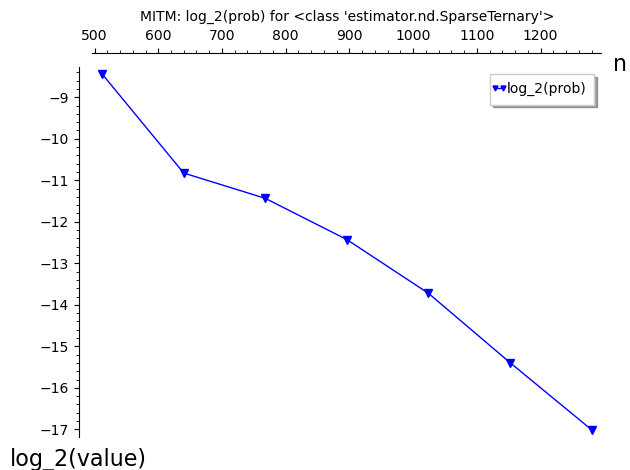

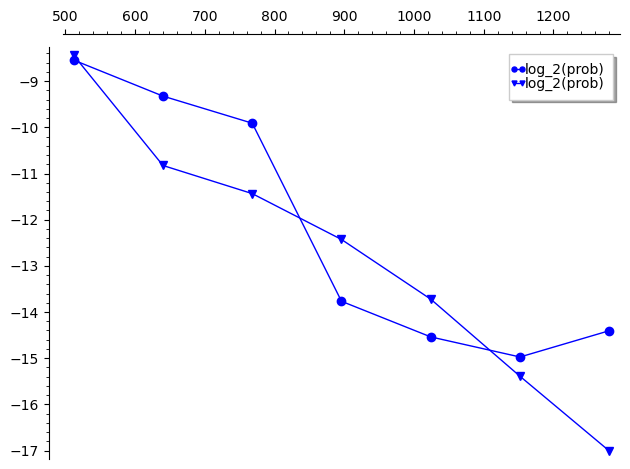

In [6]:
for Dist in distrib:
    Gprob0 = plot_series_for_distribution(
        stats_nomitm_whole, Dist, "prob", 
        log2_y=True, title_prefix="No MITM: log_2(prob) for ")
    Gprob1 = plot_series_for_distribution(
        stats_mitm_whole, Dist, "prob", 
        log2_y=True, title_prefix="MITM: log_2(prob) for ",
        marker="v")

(Gprob0+Gprob1).show()

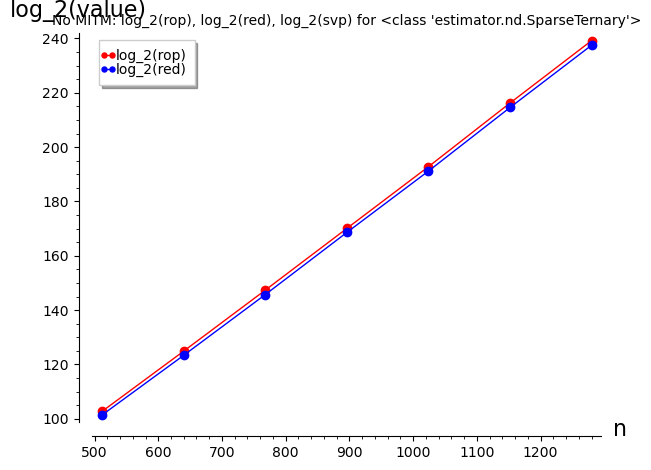

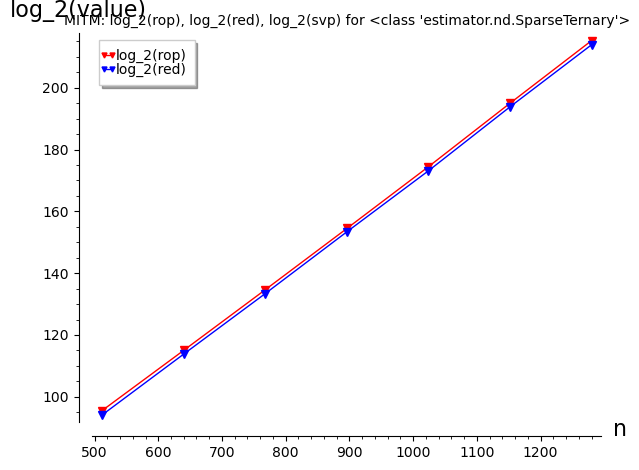

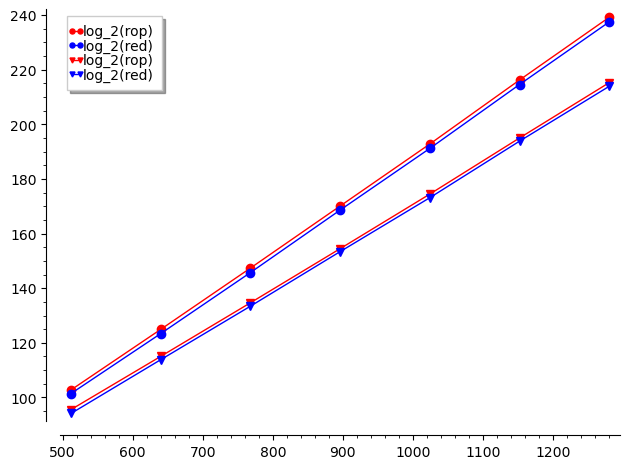

In [8]:
for Dist in distrib:
    G0 = plot_series_for_distribution(
        stats_nomitm,
        Dist,
        ["rop", "red", "svp"],
        title_prefix="No MITM: log_2(rop), log_2(red), log_2(svp) for ",
        log2_y=True,
    )

    G1 = plot_series_for_distribution(
        stats_mitm,
        Dist,
        ["rop", "red", "svp"],
        title_prefix="MITM: log_2(rop), log_2(red), log_2(svp) for ",
        log2_y=True,
        marker="v"
    )

(G0+G1).show()

In [ ]:
(G0 + G1).show()